In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama


In [5]:
model = ChatOllama(model="llama3.2:latest")

In [6]:
#create a state
class LLMState(TypedDict):
    input_text: str
    output_text: str

In [7]:
def calling_llm(state:LLMState)->LLMState:
    question=state['input_text']
    prompt=f"Answer the following question: {question}"
    response=model.invoke(prompt).content
    state['output_text']=response
    return state

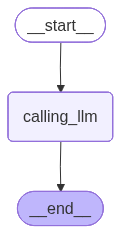

In [12]:
graph=StateGraph(LLMState)

graph.add_node("calling_llm",calling_llm)

graph.add_edge(START,"calling_llm")
graph.add_edge("calling_llm",END)

graph.compile()
# workflow=graph.compile()

In [13]:
workflow=graph.compile()
initial_input={"input_text": "What is the capital of France?"}
final_output=workflow.invoke(initial_input)
print(final_output)

{'input_text': 'What is the capital of France?', 'output_text': 'The capital of France is Paris.'}


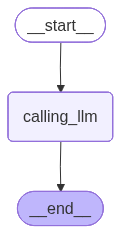

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())